# Défi quotidien : Analyse de texte de livres à l'aide d'un nuage de mots

Ce notebook couvre :
- **Section 1 – Prétraitement du texte** : chargement, nettoyage, tokenisation, stopwords, stemming, lemmatisation, POS, NER
- **Section 2 – Analyse du texte** : WordCloud, Bag of Words, graphiques circulaires
- **Section 3 – TF-IDF** : vectorisation pondérée, mots les plus pertinents par livre

---
## 0. Installation & Imports

Avant de commencer, on installe les bibliothèques nécessaires et on télécharge les ressources NLTK et spaCy.

In [1]:
# ── Installation (à exécuter une seule fois) ──────────────────────────────
# Décommentez si les bibliothèques ne sont pas encore installées :
# !pip install requests nltk spacy wordcloud matplotlib scikit-learn
# !python -m spacy download en_core_web_sm

# ── Imports ───────────────────────────────────────────────────────────────
import re                          # Expressions régulières (nettoyage texte)
import numpy as np                 # Calculs numériques (tri, tableaux)
import requests                    # Téléchargement des livres via HTTP
import matplotlib.pyplot as plt    # Affichage de graphiques

# NLTK : bibliothèque NLP classique en Python
import nltk
from nltk.tokenize import word_tokenize        # Découpage texte → liste de mots
from nltk.corpus import stopwords              # Liste de mots vides (the, is...)
from nltk.stem import PorterStemmer            # Réduction des mots à leur racine
from nltk import pos_tag, ne_chunk             # POS tagging + entités nommées

# spaCy : bibliothèque NLP moderne avec modèles pré-entraînés
import spacy

# WordCloud : génération de nuages de mots
from wordcloud import WordCloud

# Scikit-learn : vectorisation du texte
from sklearn.feature_extraction.text import CountVectorizer   # Bag of Words
from sklearn.feature_extraction.text import TfidfVectorizer   # TF-IDF

# ── Téléchargement des ressources NLTK ────────────────────────────────────
nltk.download("punkt")                          # Tokeniseur
nltk.download("punkt_tab")                      # Données punkt supplémentaires
nltk.download("stopwords")                      # Mots vides
nltk.download("averaged_perceptron_tagger")     # Modèle POS tagging
nltk.download("averaged_perceptron_tagger_eng") # Données POS anglais
nltk.download("maxent_ne_chunker")              # Modèle NER
nltk.download("maxent_ne_chunker_tab")          # Données NER
nltk.download("words")                          # Dictionnaire anglais

# ── Chargement du modèle spaCy ─────────────────────────────────────────────
# "en_core_web_sm" = petit modèle anglais pré-entraîné (lemmatisation, POS, NER)
nlp = spacy.load("en_core_web_sm")

print("Toutes les bibliothèques sont chargées avec succès !")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /r

Toutes les bibliothèques sont chargées avec succès !


---
## Section 1 : Prétraitement du texte

### Exercice 1 – Charger et nettoyer les textes depuis les URLs

On crée une fonction `load_texts()` qui :
1. Télécharge chaque livre depuis Project Gutenberg
2. Extrait le contenu principal (entre les marqueurs **START** et **END**)
3. Nettoie les caractères non-alphabétiques avec des **expressions régulières**

In [2]:
def load_texts(urls):
    """
    Télécharge des livres depuis Project Gutenberg, extrait le contenu
    principal (sans les crédits) et nettoie le texte.

    Paramètres:
        urls (list): Liste d'URLs de fichiers .txt

    Retourne:
        corpus (list): Liste de textes nettoyés, un par livre
    """
    corpus = []  # Liste qui va stocker les textes nettoyés

    for url in urls:
        # Étape 1 : Télécharger le livre
        response = requests.get(url)
        text = response.text  # Texte brut du fichier

        # Étape 2 : Supprimer les crédits Project Gutenberg
        # Les livres ont des blocs de texte légaux au début et à la fin.
        # On utilise des "marqueurs" pour repérer où commence et finit le vrai livre.
        start_marker = "*** START OF THIS PROJECT GUTENBERG EBOOK"
        end_marker   = "*** END OF THIS PROJECT GUTENBERG EBOOK"

        start_idx = text.find(start_marker)  # Position du début du livre
        end_idx   = text.find(end_marker)    # Position de la fin du livre

        if start_idx != -1 and end_idx != -1:
            # Les deux marqueurs trouvés : on extrait ce qui est entre les deux
            text = text[start_idx + len(start_marker):end_idx]
        elif start_idx != -1:
            # Seulement le marqueur de début : on prend jusqu'à la fin du fichier
            text = text[start_idx + len(start_marker):]
        elif end_idx != -1:
            # Seulement le marqueur de fin : on prend depuis le début
            text = text[:end_idx]
        # Si aucun marqueur trouvé : on garde le texte entier

        # Étape 3 : Nettoyer avec des expressions régulières (regex)
        # [^a-zA-Z\s] = tout ce qui N'est PAS une lettre ou un espace
        # On supprime : !, ?, ", ', 1, 2, 3, -, etc.
        cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Remplacer les espaces multiples (\n, \t, double espaces) par un seul espace
        cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

        corpus.append(cleaned_text)

    return corpus


# ── URLs des trois livres de Lewis Carroll (Project Gutenberg) ─────────────
book_urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",       # Alice au Pays des Merveilles
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",       # A Travers le Miroir
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"  # Un Conte Enchevetre
]

# Noms des livres pour les titres des graphiques
book_titles = [
    "Alice's Adventures in Wonderland",
    "Through the Looking-Glass",
    "A Tangled Tale"
]

# ── Chargement des livres ──────────────────────────────────────────────────
books_corpus = load_texts(book_urls)

print(f"Nombre de livres charges : {len(books_corpus)}")
for i, text in enumerate(books_corpus):
    print(f"  Livre {i+1} : {len(text)} caracteres")


Nombre de livres charges : 3
  Livre 1 : 152859 caracteres
  Livre 2 : 169386 caracteres
  Livre 3 : 161600 caracteres


### Exercice 2 – Afficher les 200 premiers caractères

On vérifie que le texte a bien été chargé et nettoyé. Les 200 premiers caractères donnent un aperçu du contenu.

> **Observation :** Il n'y a plus de ponctuation ni de chiffres. Les crédits Gutenberg ont été retirés grâce aux marqueurs START/END.

In [3]:
# Afficher les 200 premiers caractères de chaque livre
print("=" * 65)
for i, text in enumerate(books_corpus):
    print(f"\nLivre {i+1} : {book_titles[i]}")
    print("-" * 40)
    print(text[:200])  # Les 200 premiers caractères
    print()

# Remarques :
# - Le texte ne contient plus de ponctuation ni de chiffres
# - Les credits Project Gutenberg ont ete supprimes
# - Ces parties non pertinentes etaient : titre legal, nom auteur, licence...



Livre 1 : Alice's Adventures in Wonderland
----------------------------------------
The Project Gutenberg eBook of Alices Adventures in Wonderland This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restric


Livre 2 : Through the Looking-Glass
----------------------------------------
The Project Gutenberg eBook of Through the LookingGlass This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions w


Livre 3 : A Tangled Tale
----------------------------------------
The Project Gutenberg eBook of A Tangled Tale This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever 



### Exercice 3 – Tokenisation

La **tokenisation** découpe le texte en **tokens** (unités élémentaires, généralement des mots).

Exemple : `"Hello world"` → `["Hello", "world"]`

In [4]:
# Tokeniser chaque livre avec NLTK
# word_tokenize() découpe intelligemment (gère les apostrophes, abréviations...)
tokenized_books = []

for i, text in enumerate(books_corpus):
    tokens = word_tokenize(text)     # Découpage en liste de mots
    tokenized_books.append(tokens)   # Sauvegarde pour la suite

    print(f"Livre {i+1} : {book_titles[i]}")
    print(f"  Nombre total de tokens : {len(tokens)}")
    print(f"  150 premiers tokens :")
    print(f"  {tokens[:150]}")
    print("=" * 65)


Livre 1 : Alice's Adventures in Wonderland
  Nombre total de tokens : 29472
  150 premiers tokens :
  ['The', 'Project', 'Gutenberg', 'eBook', 'of', 'Alices', 'Adventures', 'in', 'Wonderland', 'This', 'eBook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'United', 'States', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever', 'You', 'may', 'copy', 'it', 'give', 'it', 'away', 'or', 'reuse', 'it', 'under', 'the', 'terms', 'of', 'the', 'Project', 'Gutenberg', 'License', 'included', 'with', 'this', 'eBook', 'or', 'online', 'at', 'wwwgutenbergorg', 'If', 'you', 'are', 'not', 'located', 'in', 'the', 'United', 'States', 'you', 'will', 'have', 'to', 'check', 'the', 'laws', 'of', 'the', 'country', 'where', 'you', 'are', 'located', 'before', 'using', 'this', 'eBook', 'Title', 'Alices', 'Adventures', 'in', 'Wonderland', 'Author', 'Lewis', 'Carroll', 'Release', 'date', 'June', 'eBook', 'Most',

### Exercice 4 – Suppression des mots vides (Stopwords)

Les **stopwords** sont des mots très fréquents qui n'apportent pas de sens :
`"the"`, `"is"`, `"I"`, `"me"`, `"we"`, `"our"`, etc.

On les supprime pour se concentrer sur les mots porteurs de sens.

In [5]:
# Récupérer la liste des stopwords anglais de NLTK
stop_words = set(stopwords.words("english"))  # set() pour une recherche plus rapide

print(f"Nombre de stopwords anglais : {len(stop_words)}")
print(f"Exemples : {list(stop_words)[:15]}")
print()

# Filtrer les stopwords de chaque livre
filtered_books = []

for i, tokens in enumerate(tokenized_books):
    # On garde un token si :
    # 1. Ce n'est pas un stopword (word.lower() not in stop_words)
    # 2. Ce sont des lettres uniquement (word.isalpha()) → élimine les nombres
    filtered = [
        word.lower()
        for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]
    filtered_books.append(filtered)

    print(f"Livre {i+1} : {book_titles[i]}")
    print(f"  Avant suppression : {len(tokens)} tokens")
    print(f"  Apres suppression : {len(filtered)} tokens")
    print(f"  Reduction : {100*(1 - len(filtered)/len(tokens)):.1f}%")
    print()

# Verification : ces stopwords sont-ils bien absents du livre 1 ?
stopwords_to_check = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves"]
print("Verification de la suppression (Livre 1) :")
for sw in stopwords_to_check:
    count = filtered_books[0].count(sw)
    status = "OK supprime" if count == 0 else f"ENCORE PRESENT ({count} fois)"
    print(f'  "{sw}" -> {status}')


Nombre de stopwords anglais : 198
Exemples : ['d', 'his', 'or', "isn't", 'as', 'no', 'other', 'mightn', "he'll", 'shan', 'few', 'all', 'this', "weren't", 'him']

Livre 1 : Alice's Adventures in Wonderland
  Avant suppression : 29472 tokens
  Apres suppression : 14357 tokens
  Reduction : 51.3%

Livre 2 : Through the Looking-Glass
  Avant suppression : 32606 tokens
  Apres suppression : 16305 tokens
  Reduction : 50.0%

Livre 3 : A Tangled Tale
  Avant suppression : 29983 tokens
  Apres suppression : 15579 tokens
  Reduction : 48.0%

Verification de la suppression (Livre 1) :
  "i" -> OK supprime
  "me" -> OK supprime
  "my" -> OK supprime
  "myself" -> OK supprime
  "we" -> OK supprime
  "our" -> OK supprime
  "ours" -> OK supprime
  "ourselves" -> OK supprime


### Exercice 5 – Stemming avec PorterStemmer

Le **stemming** réduit chaque mot à sa **racine brute** (stem) :
- `"running"` → `"run"`
- `"happily"` → `"happili"` *(pas toujours un vrai mot)*

C'est rapide mais approximatif.

In [6]:
# Initialiser le stemmer de Porter (algorithme classique de stemming)
stemmer = PorterStemmer()

# Appliquer le stemming sur les tokens filtres de chaque livre
stemmed_books = []

for i, tokens in enumerate(filtered_books):
    # stemmer.stem() retourne la racine du mot
    stemmed = [stemmer.stem(word) for word in tokens]
    stemmed_books.append(stemmed)

    print(f"Livre {i+1} : {book_titles[i]}")
    print(f"  50 premiers tokens stemmed :")
    print(f"  {stemmed[:50]}")
    print()


Livre 1 : Alice's Adventures in Wonderland
  50 premiers tokens stemmed :
  ['project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'ebook', 'use', 'anyon', 'anywher', 'unit', 'state', 'part', 'world', 'cost', 'almost', 'restrict', 'whatsoev', 'may', 'copi', 'give', 'away', 'reus', 'term', 'project', 'gutenberg', 'licens', 'includ', 'ebook', 'onlin', 'wwwgutenbergorg', 'locat', 'unit', 'state', 'check', 'law', 'countri', 'locat', 'use', 'ebook', 'titl', 'alic', 'adventur', 'wonderland', 'author', 'lewi', 'carrol', 'releas', 'date', 'june']

Livre 2 : Through the Looking-Glass
  50 premiers tokens stemmed :
  ['project', 'gutenberg', 'ebook', 'lookingglass', 'ebook', 'use', 'anyon', 'anywher', 'unit', 'state', 'part', 'world', 'cost', 'almost', 'restrict', 'whatsoev', 'may', 'copi', 'give', 'away', 'reus', 'term', 'project', 'gutenberg', 'licens', 'includ', 'ebook', 'onlin', 'wwwgutenbergorg', 'locat', 'unit', 'state', 'check', 'law', 'countri', 'locat', 'use', 'ebook', 'tit

### Exercice 6 – Lemmatisation avec spaCy

La **lemmatisation** retourne le **lemme** (forme du dictionnaire) d'un mot :
- `"running"` → `"run"`
- `"better"` → `"good"`
- `"was"` → `"be"`

On utilise l'attribut `token.lemma_` du modèle spaCy `en_core_web_sm`.

In [7]:
# Lemmatiser chaque livre avec spaCy
# nlp() analyse le texte et cree un objet Doc avec tous les attributs linguistiques
lemmatized_books = []

for i, text in enumerate(books_corpus):
    # On limite a 500 000 caracteres pour eviter de surcharger la memoire
    doc = nlp(text[:500000])

    # Extraire les lemmes en filtrant :
    # - les stopwords (token.is_stop)
    # - la ponctuation (token.is_punct)
    # - les espaces (token.is_space)
    # - les non-mots (token.is_alpha)
    lemmas = [
        token.lemma_.lower()       # Le lemme est accessible via .lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
    ]
    lemmatized_books.append(lemmas)

    print(f"Livre {i+1} : {book_titles[i]}")
    print(f"  Nombre de lemmes : {len(lemmas)}")
    print(f"  50 premiers lemmes :")
    print(f"  {lemmas[:50]}")
    print()


Livre 1 : Alice's Adventures in Wonderland
  Nombre de lemmes : 12340
  50 premiers lemmes :
  ['project', 'gutenberg', 'ebook', 'alices', 'adventures', 'wonderland', 'ebook', 'use', 'united', 'states', 'part', 'world', 'cost', 'restriction', 'whatsoever', 'copy', 'away', 'reuse', 'term', 'project', 'gutenberg', 'license', 'include', 'ebook', 'online', 'wwwgutenbergorg', 'locate', 'united', 'states', 'check', 'law', 'country', 'locate', 'ebook', 'title', 'alices', 'adventures', 'wonderland', 'author', 'lewis', 'carroll', 'release', 'date', 'june', 'ebook', 'recently', 'update', 'june', 'language', 'english']

Livre 2 : Through the Looking-Glass
  Nombre de lemmes : 13980
  50 premiers lemmes :
  ['project', 'gutenberg', 'ebook', 'lookingglass', 'ebook', 'use', 'united', 'states', 'part', 'world', 'cost', 'restriction', 'whatsoever', 'copy', 'away', 'reuse', 'term', 'project', 'gutenberg', 'license', 'include', 'ebook', 'online', 'wwwgutenbergorg', 'locate', 'united', 'states', 'check',

### Exercice 7 – Comparaison Stemming vs Lemmatisation

| Critère | Stemming (Porter) | Lemmatisation (spaCy) |
|---------|-------------------|----------------------|
| **Méthode** | Règles heuristiques | Analyse linguistique (ML) |
| **Résultat** | Racine brute | Forme du dictionnaire |
| **Exemple** | "happily" → "happili" | "happily" → "happily" |
| **Exemple** | "was" → "wa" | "was" → "be" |
| **Vitesse** | Très rapide | Plus lent |
| **Précision** | Moins précis | Plus précis |

**Conclusion :** La lemmatisation est préférable pour les tâches NLP car elle produit de vrais mots et gère les irrégularités (was→be, better→good). Le stemming est utile quand la vitesse prime.

In [10]:
# Comparaison cote a cote : Stemming vs Lemmatisation
exemples = ["running", "happily", "better", "studies", "cried", "children", "was", "mice"]

print(f'{"Mot original":<15} {"Stemming":<20} {"Lemmatisation":<20}')
print("-" * 55)

for mot in exemples:
    # Stemming
    stem = stemmer.stem(mot)

    # Lemmatisation avec spaCy
    doc = nlp(mot)
    lemme = doc[0].lemma_ if doc else mot

    print(f"{mot:<15} {stem:<20} {lemme:<20}")

print()
print("Observation : le stemming peut produire des non-mots ('happili', 'cri').")
print("La lemmatisation retourne toujours une forme valide du dictionnaire.")

Mot original    Stemming             Lemmatisation       
-------------------------------------------------------
running         run                  run                 
happily         happili              happily             
better          better               well                
studies         studi                study               
cried           cri                  cry                 
children        children             child               
was             wa                   be                  
mice            mice                 mouse               

Observation : le stemming peut produire des non-mots ('happili', 'cri').
La lemmatisation retourne toujours une forme valide du dictionnaire.


### Exercice 8 – Étiquetage grammatical (POS Tagging)

Le **POS Tagging** attribue une catégorie grammaticale à chaque mot :
- `NN` = nom singulier, `NNS` = nom pluriel
- `VB` = verbe (base), `VBD` = verbe (passé)
- `JJ` = adjectif, `RB` = adverbe
- `NNP` = nom propre

In [11]:
# Appliquer le POS tagging avec NLTK
# pos_tag() prend une liste de tokens et retourne une liste de tuples (mot, tag)

pos_books = []  # Stocker les POS tags complets pour la suite (NER)

for i, tokens in enumerate(filtered_books):
    # POS tagging sur les 50 premiers tokens pour l'affichage
    pos_sample = pos_tag(tokens[:50])

    # POS tagging complet (utilise pour la NER)
    pos_full = pos_tag(tokens)
    pos_books.append(pos_full)

    print(f"Livre {i+1} : {book_titles[i]}")
    print(f"  Format : (mot, etiquette_grammaticale)")
    print(f"  {pos_sample}")
    print()

# Legende des etiquettes
print("Legende des etiquettes POS :")
for tag, desc in [("NN","Nom singulier"), ("NNS","Nom pluriel"), ("NNP","Nom propre"),
                   ("VB","Verbe base"), ("VBD","Verbe passe"), ("VBG","Verbe -ing"),
                   ("JJ","Adjectif"), ("RB","Adverbe")]:
    print(f"  {tag:<6} = {desc}")


Livre 1 : Alice's Adventures in Wonderland
  Format : (mot, etiquette_grammaticale)
  [('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('alices', 'VBZ'), ('adventures', 'NNS'), ('wonderland', 'VBP'), ('ebook', 'NN'), ('use', 'NN'), ('anyone', 'NN'), ('anywhere', 'RB'), ('united', 'JJ'), ('states', 'NNS'), ('parts', 'NNS'), ('world', 'NN'), ('cost', 'NN'), ('almost', 'RB'), ('restrictions', 'NNS'), ('whatsoever', 'VBP'), ('may', 'MD'), ('copy', 'VB'), ('give', 'VB'), ('away', 'RP'), ('reuse', 'NN'), ('terms', 'NNS'), ('project', 'VBP'), ('gutenberg', 'JJ'), ('license', 'NN'), ('included', 'VBD'), ('ebook', 'JJ'), ('online', 'NN'), ('wwwgutenbergorg', 'NN'), ('located', 'VBN'), ('united', 'JJ'), ('states', 'NNS'), ('check', 'VBP'), ('laws', 'NNS'), ('country', 'NN'), ('located', 'VBD'), ('using', 'VBG'), ('ebook', 'NN'), ('title', 'NN'), ('alices', 'NNS'), ('adventures', 'VBZ'), ('wonderland', 'VBP'), ('author', 'NN'), ('lewis', 'NN'), ('carroll', 'NN'), ('release', 'NN'), ('dat

### Exercice 9 – Reconnaissance d'entités nommées (NER)

La **NER** identifie et classifie les entités spéciales dans le texte :
- `PERSON` : Alice, Queen, King
- `GPE` : pays, villes
- `ORGANIZATION` : organisations

In [12]:
# Reconnaissance d'entites nommees avec NLTK
# ne_chunk() analyse les POS tags et regroupe les entites dans un arbre

print("Entites nommees dans les 200 premiers tokens de chaque livre :\n")

for i, pos_full in enumerate(pos_books):
    # On travaille sur un extrait (200 tokens) pour la lisibilite
    pos_sample = pos_full[:200]

    # ne_chunk() retourne un arbre : les entites sont des sous-arbres etiquetes
    chunked = ne_chunk(pos_sample)

    # Extraire les entites de l'arbre
    entities = []
    for subtree in chunked:
        if hasattr(subtree, "label"):  # Si c'est un sous-arbre = une entite
            name = " ".join([word for word, tag in subtree.leaves()])
            etype = subtree.label()    # Type : PERSON, GPE, ORGANIZATION...
            entities.append((name, etype))

    print(f"Livre {i+1} : {book_titles[i]}")
    if entities:
        for name, etype in entities[:20]:
            print(f"  [{etype}] {name}")
    else:
        print("  Aucune entite trouvee dans cet extrait")
    print()


Entites nommees dans les 200 premiers tokens de chaque livre :

Livre 1 : Alice's Adventures in Wonderland
  Aucune entite trouvee dans cet extrait

Livre 2 : Through the Looking-Glass
  Aucune entite trouvee dans cet extrait

Livre 3 : A Tangled Tale
  Aucune entite trouvee dans cet extrait



---
## Section 2 : Analyse du texte

### Exercice 1 – Nuage de mots (WordCloud)

Un **nuage de mots** visualise les fréquences : plus un mot est fréquent, plus il est grand.

On utilise les textes **filtrés** (sans stopwords) pour que les mots significatifs ressortent.

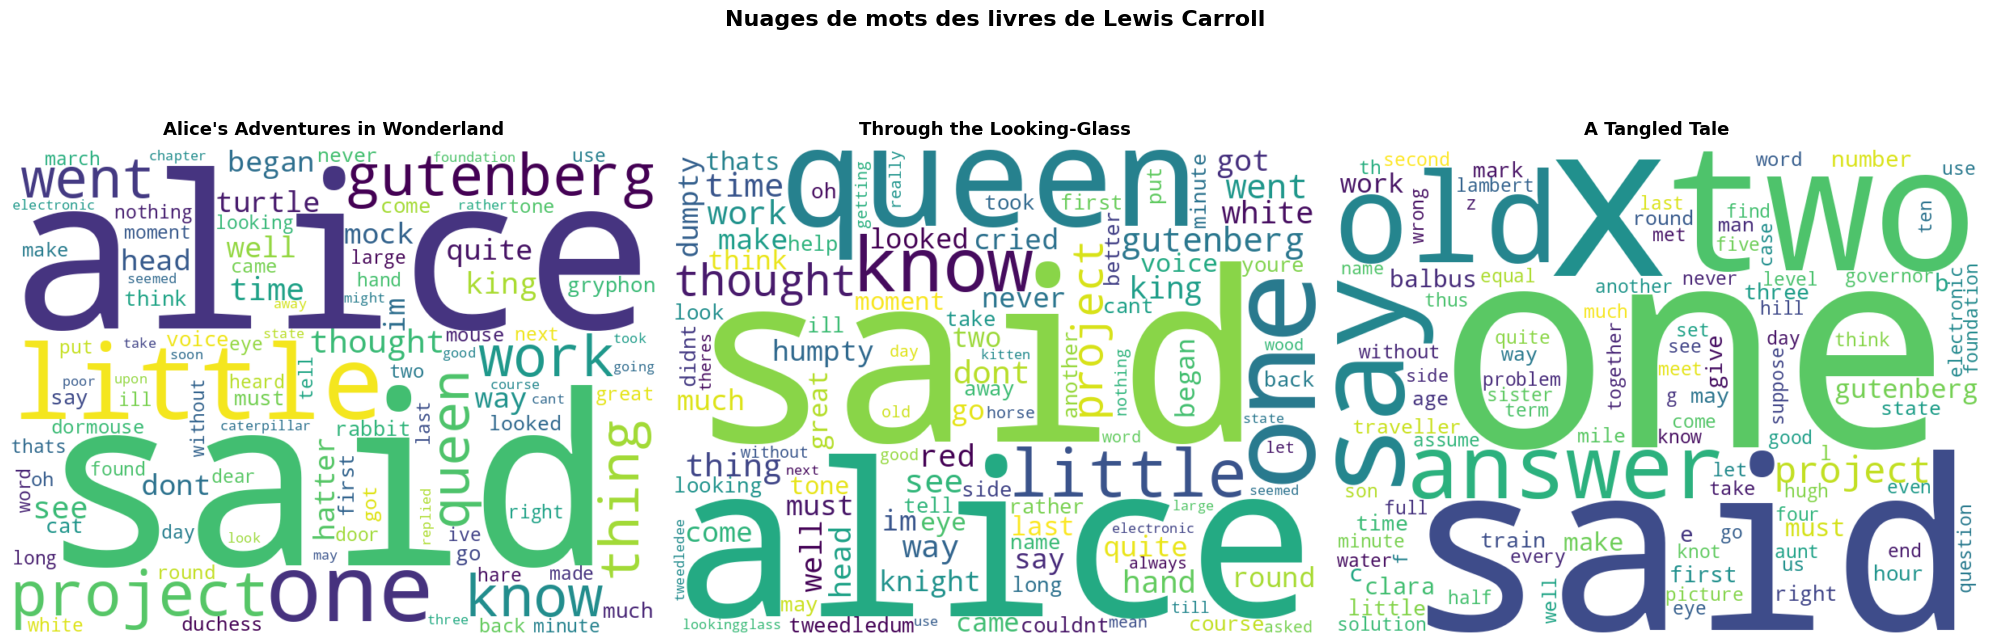

Les mots les plus grands = les plus frequents dans chaque livre.
On voit 'alice' dominer dans les 3 livres (personnage principal).


In [13]:
# Creer un nuage de mots pour chaque livre
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, tokens in enumerate(filtered_books):
    # Reconstituer le texte filtre : WordCloud prend une chaine, pas une liste
    text_filtered = " ".join(tokens)

    # Creer le nuage de mots
    wordcloud = WordCloud(
        width=800,                # Largeur en pixels
        height=600,               # Hauteur en pixels
        background_color="white", # Fond blanc
        max_words=100,            # Max 100 mots affiches
        colormap="viridis",       # Palette vert/bleu/violet
        collocations=False        # Eviter les bigrammes automatiques
    ).generate(text_filtered)

    # Afficher dans le sous-graphique
    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")  # Masquer les axes (inutiles pour une image)
    axes[i].set_title(book_titles[i], fontsize=13, fontweight="bold", pad=10)

plt.suptitle("Nuages de mots des livres de Lewis Carroll",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Les mots les plus grands = les plus frequents dans chaque livre.")
print("On voit 'alice' dominer dans les 3 livres (personnage principal).")


### Exercice 2 – Bag of Words (BoW) : 5 mots les plus fréquents

Le **Bag of Words** transforme chaque document en un vecteur de comptage des mots.

> **Meilleur texte d'entrée :** le texte **lemmatisé** car il regroupe les formes d'un même mot
> (`"run"`, `"running"`, `"ran"` → tous réduits à `"run"`).

In [14]:
# Preparer les textes lemmatises (reconstituer en chaines)
lemmatized_texts = [" ".join(tokens) for tokens in lemmatized_books]

# Creer le vectoriseur Bag of Words
# CountVectorizer compte les occurrences de chaque mot dans chaque document
vectorizer = CountVectorizer(
    max_features=1000,      # Garder les 1000 mots les plus frequents
    stop_words="english"    # Supprimer encore les stopwords
)

# fit_transform() : apprend le vocabulaire + transforme les textes en matrice
# Resultat : matrice (n_documents x n_mots) avec le nombre d'occurrences
bow_matrix = vectorizer.fit_transform(lemmatized_texts)

# Les noms des colonnes = le vocabulaire
feature_names = vectorizer.get_feature_names_out()

print("=== Bag of Words ===")
print(f"Taille de la matrice : {bow_matrix.shape}")
print(f"  -> {bow_matrix.shape[0]} documents x {bow_matrix.shape[1]} mots uniques")
print()

# Trouver et afficher les 5 mots les plus frequents par livre
top5_bow = []  # On stocke pour les graphiques

for i in range(bow_matrix.shape[0]):
    row = bow_matrix[i].toarray()[0]        # Ligne i : frequences de tous les mots
    top5_idx = row.argsort()[-5:][::-1]    # Indices des 5 plus grands (desc.)
    top5 = [(feature_names[j], int(row[j])) for j in top5_idx]
    top5_bow.append(top5)

    print(f"Livre {i+1} : {book_titles[i]}")
    for word, count in top5:
        print(f'  "{word}" -> {count} fois')
    print()


=== Bag of Words ===
Taille de la matrice : (3, 1000)
  -> 3 documents x 1000 mots uniques

Livre 1 : Alice's Adventures in Wonderland
  "say" -> 479 fois
  "alice" -> 385 fois
  "little" -> 129 fois
  "think" -> 128 fois
  "know" -> 106 fois

Livre 2 : Through the Looking-Glass
  "say" -> 487 fois
  "alice" -> 441 fois
  "queen" -> 182 fois
  "know" -> 136 fois
  "think" -> 135 fois

Livre 3 : A Tangled Tale
  "say" -> 186 fois
  "answer" -> 95 fois
  "old" -> 95 fois
  "work" -> 90 fois
  "project" -> 88 fois



### Exercice 3 – Structure interne de la matrice BoW

On affiche la matrice au format **(document, index_mot) → fréquence** pour comprendre comment les données sont stockées.

In [15]:
# Afficher la matrice BoW en format sparse
# "Sparse" = creuse : on ne stocke que les valeurs non-zero pour economiser la memoire
print("Structure sparse de la matrice BoW :")
print("Format : (numero_document, index_mot) -> frequence")
print("-" * 50)
print(bow_matrix[:, :20])  # Les 20 premieres colonnes du vocabulaire

# Explication
print("\nLecture : (0, 5) 3  signifie que le mot d'index 5 apparait 3 fois dans le doc 0")
print()

# Exemple concret pour chaque livre
print("Exemples concrets :")
for i in range(3):
    row = bow_matrix[i].toarray()[0]
    max_idx = row.argmax()
    print(f"  Doc {i} -> mot index {max_idx} (\"{feature_names[max_idx]}\") : {int(row[max_idx])} occurrences")


Structure sparse de la matrice BoW :
Format : (numero_document, index_mot) -> frequence
--------------------------------------------------
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 58 stored elements and shape (3, 20)>
  Coords	Values
  (0, 19)	17
  (0, 18)	385
  (0, 16)	15
  (0, 9)	12
  (0, 15)	5
  (0, 10)	4
  (0, 12)	2
  (0, 5)	24
  (0, 8)	5
  (0, 17)	2
  (0, 3)	2
  (0, 13)	12
  (0, 0)	4
  (0, 14)	18
  (0, 1)	11
  (0, 6)	2
  (0, 4)	2
  (0, 7)	3
  (0, 2)	2
  (1, 19)	21
  (1, 18)	441
  (1, 16)	15
  (1, 9)	15
  (1, 15)	4
  (1, 10)	4
  :	:
  (1, 1)	11
  (1, 6)	5
  (1, 4)	3
  (1, 7)	3
  (1, 2)	2
  (1, 11)	6
  (2, 19)	1
  (2, 18)	3
  (2, 16)	1
  (2, 15)	3
  (2, 10)	40
  (2, 12)	3
  (2, 5)	35
  (2, 8)	4
  (2, 17)	2
  (2, 3)	6
  (2, 13)	12
  (2, 0)	5
  (2, 14)	20
  (2, 1)	11
  (2, 6)	7
  (2, 4)	2
  (2, 7)	7
  (2, 2)	4
  (2, 11)	5

Lecture : (0, 5) 3  signifie que le mot d'index 5 apparait 3 fois dans le doc 0

Exemples concrets :
  Doc 0 -> mot index 752 ("say") : 479 occur

### Exercice 4 – Graphique circulaire des top 5 mots (BoW)

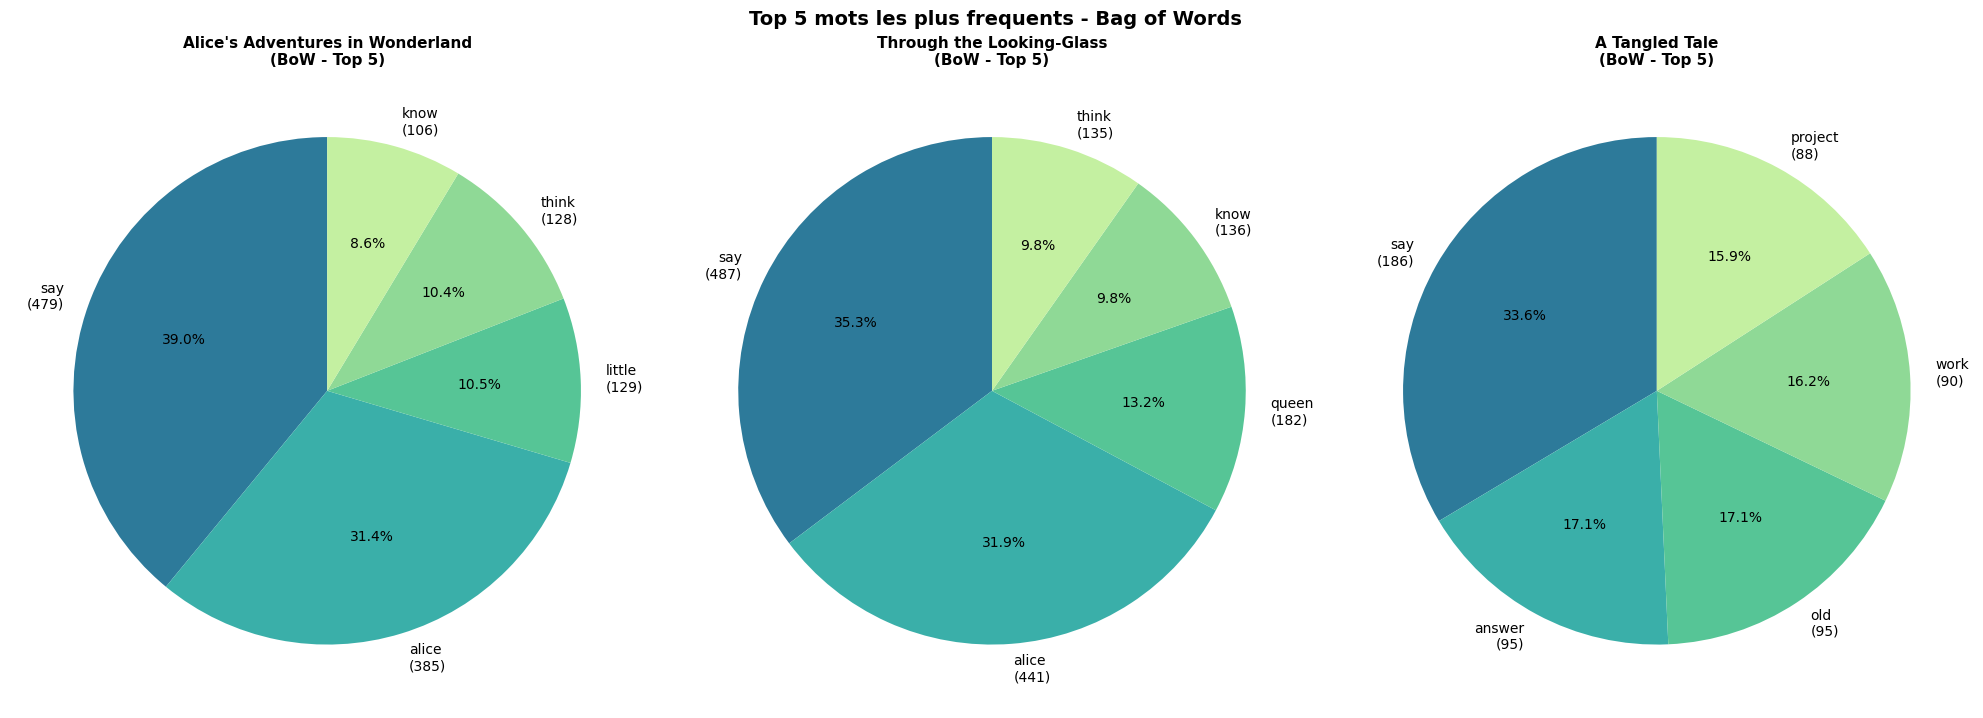

In [16]:
# Graphiques circulaires pour les top 5 mots BoW de chaque livre
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, (ax, top5) in enumerate(zip(axes, top5_bow)):
    words  = [item[0] for item in top5]           # Mots
    counts = [int(item[1]) for item in top5]      # Frequences
    labels = [f"{w}\n({c})" for w, c in zip(words, counts)]  # Etiquettes

    colors = ["#2d7a9a", "#3aafa9", "#56c596", "#8fd996", "#c4f0a1"]

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=labels,       # "mot (frequence)" autour du graphique
        autopct="%1.1f%%",  # Pourcentage a l'interieur
        colors=colors,
        startangle=90,
        textprops={"fontsize": 10}
    )
    ax.set_title(f"{book_titles[i]}\n(BoW - Top 5)", fontsize=11, fontweight="bold")

plt.suptitle("Top 5 mots les plus frequents - Bag of Words",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Exercice 5 – Analyse des résultats BoW

**Ces mots sont-ils informatifs ?**

Non, pas vraiment. Les mots les plus fréquents avec BoW (`"alice"`, `"say"`, `"look"`, `"come"`, `"go"`) sont **attendus** dans un livre sur Alice. Ils apparaissent dans les 3 livres et ne distinguent pas bien un livre de l'autre.

**Problème fondamental de BoW :** il traite tous les mots de manière égale. Un mot fréquent dans **tous** les documents est considéré aussi important qu'un mot fréquent dans **un seul** document.

**Solution → TF-IDF** : pondère l'importance d'un mot en tenant compte de sa rareté dans le corpus.

---
## Section 3 : TF-IDF – Résoudre le problème de fréquence

**TF-IDF** = Term Frequency × Inverse Document Frequency

- **TF** : fréquence du mot dans UN document
- **IDF** : log(nombre total de docs / nombre de docs contenant le mot)
- **Résultat :** un mot fréquent dans UN seul livre → score élevé ✓
- **Résultat :** un mot fréquent dans TOUS les livres → score faible ✗

In [17]:
# Creer le vectoriseur TF-IDF
# min_df=1 : garder les mots presents dans au moins 1 document
# max_df=2 : exclure les mots presents dans PLUS de 2 documents
# -> Avec seulement 3 livres, max_df=2 force TF-IDF a valoriser
#    les mots specifiques a UN ou DEUX livres (pas dans tous les 3)
tfidf_vectorizer = TfidfVectorizer(
    min_df=1,
    max_df=2,
    stop_words="english",
    max_features=5000
)

# Appliquer TF-IDF sur les textes lemmatises
tfidf_matrix = tfidf_vectorizer.fit_transform(lemmatized_texts)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("=== TF-IDF ===")
print(f"Taille de la matrice : {tfidf_matrix.shape}")
print(f"  -> {tfidf_matrix.shape[0]} documents x {tfidf_matrix.shape[1]} mots")
print()

# Top 5 mots TF-IDF par livre
top5_tfidf = []

for i in range(tfidf_matrix.shape[0]):
    row = tfidf_matrix[i].toarray()[0]
    top5_idx = row.argsort()[-5:][::-1]
    top5 = [(tfidf_feature_names[j], round(row[j], 4)) for j in top5_idx]
    top5_tfidf.append(top5)

    print(f"Livre {i+1} : {book_titles[i]}")
    for word, score in top5:
        print(f'  "{word}" -> score TF-IDF = {score}')
    print()


=== TF-IDF ===
Taille de la matrice : (3, 4510)
  -> 3 documents x 4510 mots

Livre 1 : Alice's Adventures in Wonderland
  "gryphon" -> score TF-IDF = 0.3498
  "rabbit" -> score TF-IDF = 0.2862
  "turtle" -> score TF-IDF = 0.2806
  "mock" -> score TF-IDF = 0.2757
  "hatter" -> score TF-IDF = 0.2709

Livre 2 : Through the Looking-Glass
  "humpty" -> score TF-IDF = 0.3603
  "dumpty" -> score TF-IDF = 0.3539
  "knight" -> score TF-IDF = 0.2838
  "tweedledum" -> score TF-IDF = 0.2316
  "horse" -> score TF-IDF = 0.1866

Livre 3 : A Tangled Tale
  "balbus" -> score TF-IDF = 0.3301
  "clara" -> score TF-IDF = 0.2701
  "traveller" -> score TF-IDF = 0.205
  "train" -> score TF-IDF = 0.1978
  "hugh" -> score TF-IDF = 0.155



### Exercice 2 – Graphiques circulaires TF-IDF

On visualise les 5 mots les plus **pertinents** (selon TF-IDF) de chaque livre.

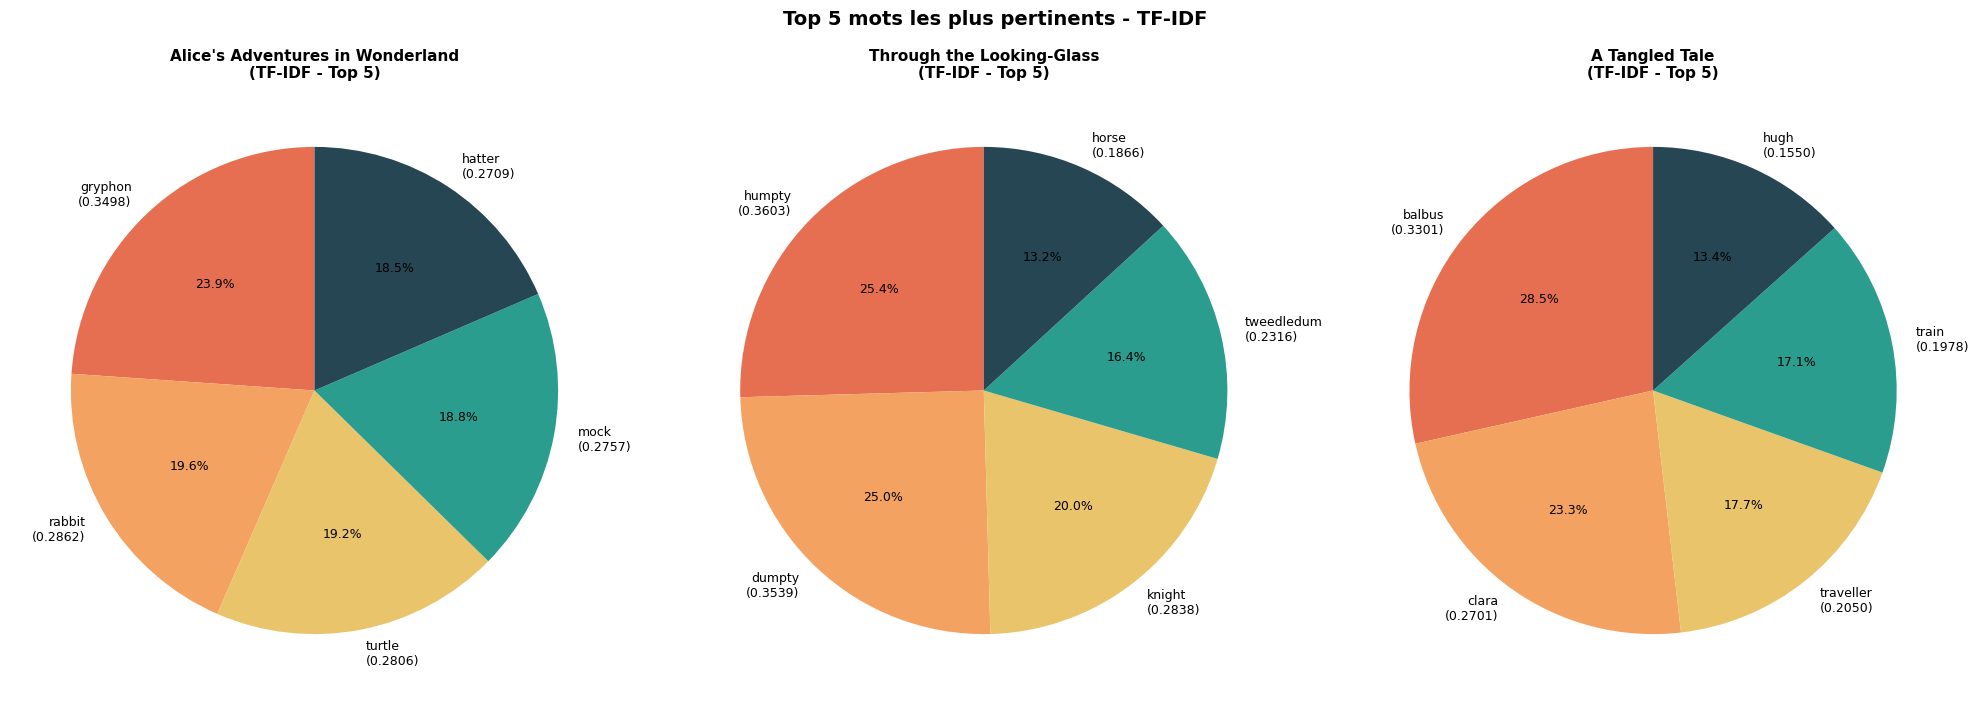

Observation : les mots TF-IDF sont plus SPECIFIQUES a chaque livre.
Contrairement a BoW, 'alice' ne domine plus tous les documents.
TF-IDF revele les mots qui DISTINGUENT chaque livre du reste du corpus.


In [18]:
# Graphiques circulaires pour les top 5 mots TF-IDF de chaque livre
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, (ax, top5) in enumerate(zip(axes, top5_tfidf)):
    words  = [item[0] for item in top5]
    scores = [item[1] for item in top5]
    labels = [f"{w}\n({s:.4f})" for w, s in zip(words, scores)]

    # Palette de couleurs differente du BoW pour distinguer visuellement
    colors = ["#e76f51", "#f4a261", "#e9c46a", "#2a9d8f", "#264653"]

    wedges, texts, autotexts = ax.pie(
        scores,
        labels=labels,
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
        textprops={"fontsize": 9}
    )
    ax.set_title(f"{book_titles[i]}\n(TF-IDF - Top 5)", fontsize=11, fontweight="bold")

plt.suptitle("Top 5 mots les plus pertinents - TF-IDF",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Observation : les mots TF-IDF sont plus SPECIFIQUES a chaque livre.")
print("Contrairement a BoW, 'alice' ne domine plus tous les documents.")
print("TF-IDF revele les mots qui DISTINGUENT chaque livre du reste du corpus.")


---
## Conclusion generale

| Technique | Usage | Avantage | Limite |
|-----------|-------|----------|--------|
| **Tokenisation** | Découpage en mots | Simple | Sensible aux majuscules |
| **Stopwords** | Suppression mots vides | Réduit le bruit | Peut supprimer du sens |
| **Stemming** | Racine brute | Rapide | Non-mots possibles |
| **Lemmatisation** | Forme dictionnaire | Précis | Plus lent |
| **POS Tagging** | Catégories grammaticales | Analyse syntaxique | |
| **NER** | Entités nommées | Extraction d'info | |
| **BoW** | Vecteur de comptage | Simple | Favorise mots globaux |
| **TF-IDF** | Pondération relative | Mots discriminants | Ignore le sens |

**Pour aller plus loin :** Word2Vec, GloVe, BERT, transformers...